In [36]:
import sys
import os

# Add project root to sys.path
project_root = os.path.abspath("..")  # parent of notebooks/
if project_root not in sys.path:
    sys.path.append(project_root)


In [37]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.preprocessing import load_data, preprocess_dataframe



In [38]:
# Load dataset
df = load_data("../data/dataset.csv")
df = preprocess_dataframe(df)

df.head()



,id,text,decision_label,clean_text
0,1,I bought the shoes immediately after seeing a ...,impulsive,i bought the shoes immediately after seeing a ...
1,2,I carefully compared multiple shoe brands befo...,deliberate,i carefully compared multiple shoe brands befo...
2,3,I sent the email in anger without rereading it,impulsive,i sent the email in anger without rereading it
3,4,I waited and rewrote the email after calming down,deliberate,i waited and rewrote the email after calming down
4,5,I ordered fast food late at night due to cravings,impulsive,i ordered fast food late at night due to cravings


In [39]:
model = joblib.load("../results/logistic_model.pkl")
vectorizer = joblib.load("../results/tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully")



Model and vectorizer loaded successfully


In [40]:
X = vectorizer.transform(df["clean_text"])
y = df["decision_label"]

print("Feature matrix shape:", X.shape)




Feature matrix shape: (321, 1292)


In [41]:
y_pred = model.predict(X)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y, y_pred))


Accuracy: 0.9719626168224299

Classification Report:

              precision    recall  f1-score   support

  deliberate       0.95      1.00      0.97       161
   impulsive       1.00      0.94      0.97       160

    accuracy                           0.97       321
   macro avg       0.97      0.97      0.97       321
weighted avg       0.97      0.97      0.97       321



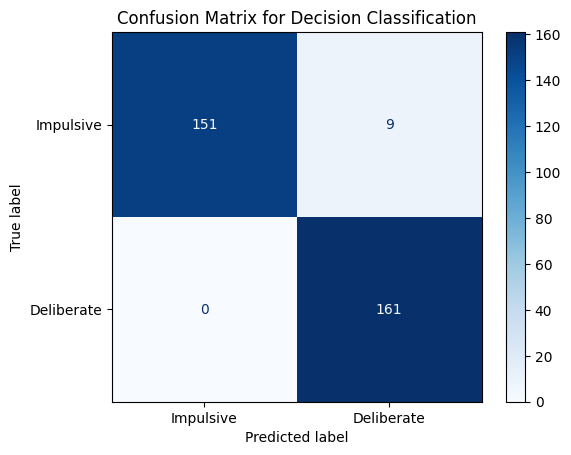

In [42]:
cm = confusion_matrix(y, y_pred, labels=["impulsive", "deliberate"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Impulsive", "Deliberate"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Decision Classification")
plt.show()


In [43]:
# Sample new texts
sample_sentences = [
    "I bought the phone immediately without thinking much",
    "I compared multiple options carefully before making a decision",
    "I booked the tickets in excitement",
    "After analysing my budget, I decided to postpone the purchase"
]

cleaned = [s.lower() for s in sample_sentences]
X_sample = vectorizer.transform(cleaned)
predictions = model.predict(X_sample)

for s, p in zip(sample_sentences, predictions):
    print(f"Sentence: {s}")
    print(f"Predicted Decision: {p}\n")


Sentence: I bought the phone immediately without thinking much
Predicted Decision: impulsive

Sentence: I compared multiple options carefully before making a decision
Predicted Decision: deliberate

Sentence: I booked the tickets in excitement
Predicted Decision: impulsive

Sentence: After analysing my budget, I decided to postpone the purchase
Predicted Decision: deliberate



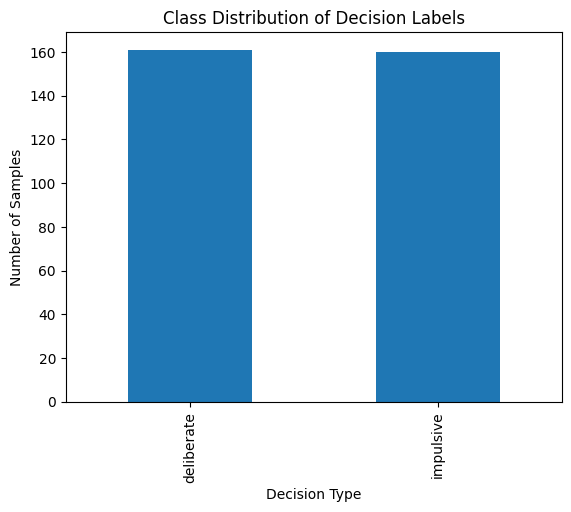

In [44]:
import matplotlib.pyplot as plt

df["decision_label"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Decision Labels")
plt.xlabel("Decision Type")
plt.ylabel("Number of Samples")
plt.show()
